Bước 1: Import thư viện và đọc dữ liệu

In [12]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F

from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml import Pipeline

import matplotlib.pyplot as plt
import seaborn as sns

spark = SparkSession.builder \
    .appName("Predict_Order_Grand_Total") \
    .getOrCreate()

spark.conf.set("spark.sql.ansi.enabled", "false")

HDFS_PATH = "hdfs://localhost:9000/ecom/ecom_clean_final"

df = spark.read \
    .option("header", True) \
    .option("inferSchema", False) \
    .csv(HDFS_PATH)

print("Số dòng ban đầu:", df.count())
print("Số cột ban đầu:", len(df.columns))

df.show(5, truncate=False)

Số dòng ban đầu: 429296
Số cột ban đầu: 16
+-------+--------+----------+-----------------------------------+------+-----------+-----------+------------+-----------------+---------------------+---------------+--------------+-----------+------------+----------+-----------+
|item_id|status  |created_at|sku                                |price |qty_ordered|grand_total|increment_id|category_name_1  |sales_commission_code|discount_amount|payment_method|customer_id|created_date|order_year|order_month|
+-------+--------+----------+-----------------------------------+------+-----------+-----------+------------+-----------------+---------------------+---------------+--------------+-----------+------------+----------+-----------+
|211313 |complete|7/1/2016  |RS_Kaju Barfi                      |425.0 |1.0        |1125.0     |100147569   |Soghaat          |unknown              |0.0            |cod           |57         |2016-07-01  |2016      |7          |
|211630 |complete|7/1/2016  |HR_Pani Puri

Bước 2: Ép kiểu dữ liệu

In [13]:
def clean_double(c):
    return F.expr(f"""
        try_cast(
            regexp_replace(
                regexp_replace(trim(`{c}`), ',', ''),
                '[^0-9.-]',
                ''
            ) AS double
        )
    """)

def clean_int(c):
    return F.expr(f"""
        try_cast(
            regexp_replace(trim(`{c}`), '[^0-9-]', '') AS int
        )
    """)


df = df \
    .withColumn("grand_total", clean_double("grand_total")) \
    .withColumn("price", clean_double("price")) \
    .withColumn("qty_ordered", clean_double("qty_ordered")) \
    .withColumn("discount_amount", clean_double("discount_amount")) \
    .withColumn("order_year", clean_int("order_year")) \
    .withColumn("order_month", clean_int("order_month")) \
    .withColumn("customer_id", clean_int("customer_id"))

Bước 3: Gom nhóm dữ liệu theo đơn hàng (increment_id) và đặt tên biến chính grand_total = label

In [ ]:
order_df = df.groupBy("increment_id").agg(
    F.max("grand_total").alias("label"),
    F.sum("qty_ordered").alias("total_qty"),
    F.count("*").alias("item_count"),
    F.avg("price").alias("avg_price"),
    F.max("price").alias("max_price"),
    F.min("price").alias("min_price"),
    F.sum("discount_amount").alias("total_discount"),
    F.countDistinct("category_name_1").alias("category_count"),
    F.first("category_name_1", ignorenulls=True).alias("main_category"),
    F.first("payment_method", ignorenulls=True).alias("payment_method"),
    F.first("order_year", ignorenulls=True).alias("order_year"),
    F.first("order_month", ignorenulls=True).alias("order_month")
)

print("Số dòng sau khi gom theo đơn hàng:", order_df.count())

order_df.select(
    "increment_id",
    "label",
    "total_qty",
    "item_count",
    "avg_price",
    "max_price",
    "total_discount",
    "category_count",
    "main_category",
    "payment_method"
).show(20, truncate=False)

Số dòng sau khi gom theo đơn hàng: 296090
+------------+------+---------+----------+---------+---------+--------------+--------------+-----------------+--------------+
|increment_id|label |total_qty|item_count|avg_price|max_price|total_discount|category_count|main_category    |payment_method|
+------------+------+---------+----------+---------+---------+--------------+--------------+-----------------+--------------+
|100147470   |3672.0|1.0      |1         |3672.0   |3672.0   |0.0           |1             |Home & Living    |cod           |
|100147479   |425.0 |1.0      |1         |425.0    |425.0    |0.0           |1             |Soghaat          |cod           |
|100147500   |350.0 |1.0      |1         |350.0    |350.0    |0.0           |1             |Soghaat          |cod           |
|100147501   |1195.0|2.0      |2         |597.5    |760.0    |0.0           |1             |Soghaat          |cod           |
|100147507   |1195.0|2.0      |2         |597.5    |760.0    |0.0           

Bước 3. Tiếp tục xử lý giá trị ngoại lai sau khi gom nhóm dữ liệu theo đơn hàng

In [15]:
order_df.select("label").describe().show()

q1, q3 = order_df.approxQuantile("label", [0.25, 0.75], 0.01)

iqr = q3 - q1
lower_bound = max(0, q1 - 3.0 * iqr)
upper_bound = q3 + 3.0 * iqr

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

print("Trước xử lý ngoại lai:", order_df.count())

outliers = order_df.filter(
    (F.col("label") < lower_bound) |
    (F.col("label") > upper_bound)
)

print("Số dòng ngoại lai:", outliers.count())

outliers.select(
    "increment_id",
    "label",
    "total_qty",
    "item_count",
    "avg_price",
    "total_discount"
).orderBy(F.desc("label")).show(30, truncate=False)

dataset = order_df.filter(
    (F.col("label") >= lower_bound) &
    (F.col("label") <= upper_bound)
)

+-------+------------------+
|summary|             label|
+-------+------------------+
|  count|            296090|
|   mean|3128.2256123949123|
| stddev| 3927.343863020849|
|    min|               0.0|
|    max|          15928.05|
+-------+------------------+

Q1: 649.0
Q3: 3770.0
IQR: 3121.0
Lower bound: 0
Upper bound: 13133.0
Trước xử lý ngoại lai: 296090
Số dòng ngoại lai: 11070
+------------+--------+---------+----------+------------------+--------------+
|increment_id|label   |total_qty|item_count|avg_price         |total_discount|
+------------+--------+---------+----------+------------------+--------------+
|100317409   |15928.05|1.0      |1         |17819.0           |1890.95       |
|100317701   |15928.05|1.0      |1         |17819.0           |1890.95       |
|100317435   |15928.05|1.0      |1         |17819.0           |1890.95       |
|100419888   |15927.25|1.0      |1         |18555.0           |2627.75       |
|100421727   |15927.25|1.0      |1         |18555.0          

In [16]:
print("Sau xử lý ngoại lai:", dataset.count())

dataset.select("label").describe().show()

Sau xử lý ngoại lai: 285020
+-------+-----------------+
|summary|            label|
+-------+-----------------+
|  count|           285020|
|   mean|2688.783486962337|
| stddev|3291.789958606185|
|    min|              0.0|
|    max|         13129.05|
+-------+-----------------+



Bước 4: Pipeline MLlib

In [17]:
feature_cols = [
    "total_qty",
    "item_count",
    "avg_price",
    "max_price",
    "min_price",
    "total_discount",
    "category_count",
    "order_year",
    "order_month"
]

category_indexer = StringIndexer(
    inputCol="main_category",
    outputCol="category_index",
    handleInvalid="keep"
)

payment_indexer = StringIndexer(
    inputCol="payment_method",
    outputCol="payment_index",
    handleInvalid="keep"
)

encoder = OneHotEncoder(
    inputCols=["category_index", "payment_index"],
    outputCols=["category_vec", "payment_vec"]
)

assembler = VectorAssembler(
    inputCols=feature_cols + ["category_vec", "payment_vec"],
    outputCol="raw_features",
    handleInvalid="skip"
)

scaler = StandardScaler(
    inputCol="raw_features",
    outputCol="features",
    withStd=True,
    withMean=False
)

pipeline = Pipeline(stages=[
    category_indexer,
    payment_indexer,
    encoder,
    assembler,
    scaler
])

pipeline_model = pipeline.fit(dataset)

df_final = pipeline_model.transform(dataset)

df_final.select(
    "increment_id",
    "label",
    "features"
).show(5, truncate=False)

+------------+------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|increment_id|label |features                                                                                                                                                                                                                   |
+------------+------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|100147470   |3672.0|(42,[0,1,2,3,4,6,7,8,15,24],[0.8456471551132454,0.8456471551132454,0.8772730625766335,0.8703448285735084,0.873101200593908,2.286394651906482,2827.042977439955,2.007694284208531,4.870387643413077,2.0072495952996827])    |
|100147479   |425.0 |(42,[0,1,2,

Bước 5: Chia train/test

In [19]:
train_data, test_data = df_final.randomSplit([0.8, 0.2], seed=42)

print("Train:", train_data.count())
print("Test :", test_data.count())

Train: 228382
Test : 56638


Bước 6: Train Linear Regression

In [20]:
lr = LinearRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=100,
    regParam=1.0,
    elasticNetParam=0.0
)

lr_model = lr.fit(train_data)

predictions = lr_model.transform(test_data)

predictions = predictions.withColumn(
    "prediction",
    F.when(F.col("prediction") < 0, 0).otherwise(F.col("prediction"))
)

predictions.select(
    "increment_id",
    F.round("label", 2).alias("actual_grand_total"),
    F.round("prediction", 2).alias("predicted_grand_total")
).show(30, truncate=False)

+------------+------------------+---------------------+
|increment_id|actual_grand_total|predicted_grand_total|
+------------+------------------+---------------------+
|100147500   |350.0             |299.91               |
|100147522   |320.0             |573.26               |
|100147587   |320.0             |573.26               |
|100147664   |150.0             |179.47               |
|100147714   |165.0             |299.91               |
|100147738   |360.0             |597.35               |
|100147837   |2950.0            |2157.15              |
|100147956   |2340.0            |1789.78              |
|100148158   |12600.0           |8502.22              |
|100148162   |3395.0            |2377.04              |
|100148178   |2499.0            |1838.16              |
|100148221   |510.0             |396.27               |
|100148326   |360.0             |597.35               |
|100148382   |150.0             |287.75               |
|100148454   |10500.0           |5236.09        

Bước 7: Đánh giá mô hình

In [21]:
rmse_eval = RegressionEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="rmse"
)

mae_eval = RegressionEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="mae"
)

r2_eval = RegressionEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="r2"
)

rmse = rmse_eval.evaluate(predictions)
mae = mae_eval.evaluate(predictions)
r2 = r2_eval.evaluate(predictions)

print("===== ĐÁNH GIÁ MÔ HÌNH LINEAR REGRESSION THEO CẤP ĐƠN HÀNG =====")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R2  : {r2:.4f}")

===== ĐÁNH GIÁ MÔ HÌNH LINEAR REGRESSION THEO CẤP ĐƠN HÀNG =====
RMSE: 1624.5899
MAE : 786.4832
R2  : 0.7521


Bước 8: Vẽ biểu đồ

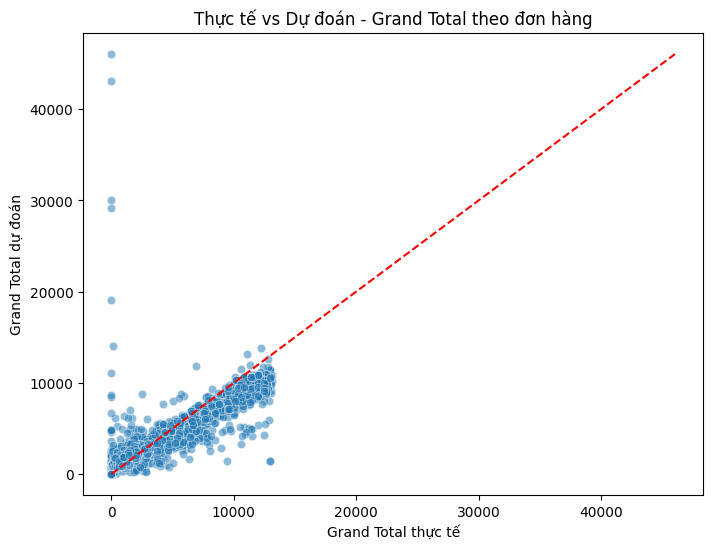

In [22]:
pd_preds = predictions.select("label", "prediction") \
    .sample(False, 0.1, seed=42) \
    .toPandas()

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x="label",
    y="prediction",
    data=pd_preds,
    alpha=0.5
)

max_value = max(pd_preds["label"].max(), pd_preds["prediction"].max())

plt.plot(
    [0, max_value],
    [0, max_value],
    color="red",
    linestyle="--"
)

plt.title("Thực tế vs Dự đoán - Grand Total theo đơn hàng")
plt.xlabel("Grand Total thực tế")
plt.ylabel("Grand Total dự đoán")
plt.show()